Sampling Rate: 22050


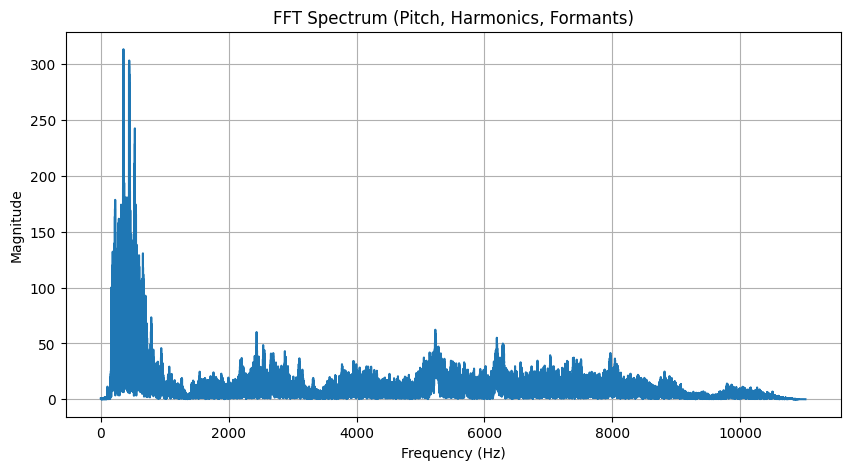

Pitch from FFT (Hz): 353.0968769210614


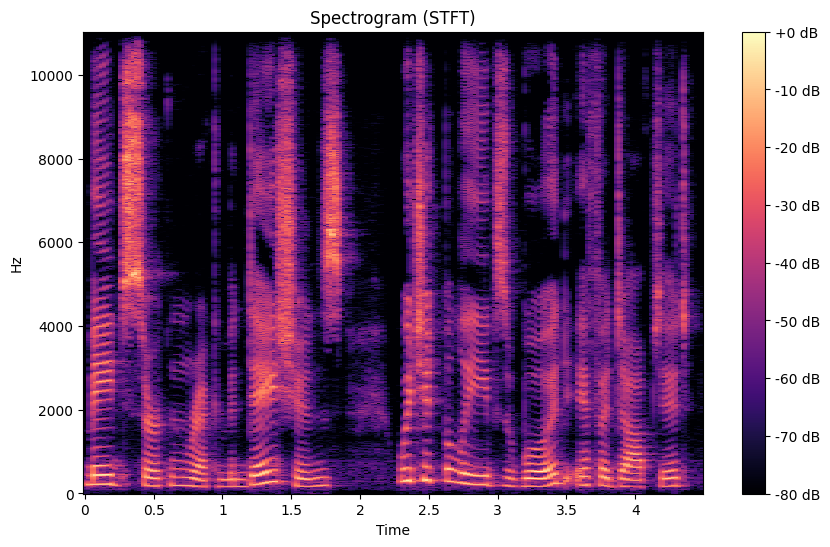

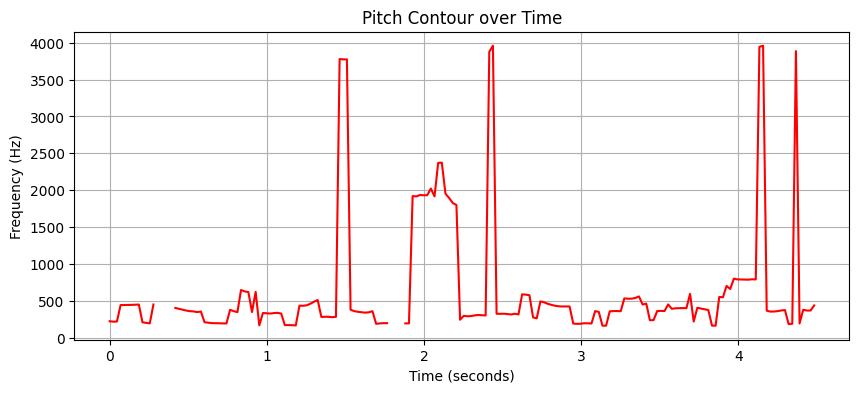

Estimated Formants (Hz): [np.float32(0.0), np.float32(0.0), np.float32(2798.0098), np.float32(5097.6265)]


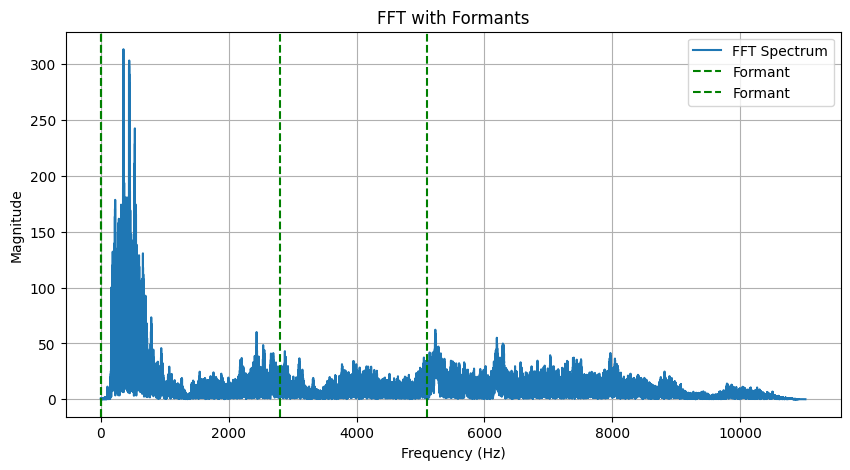

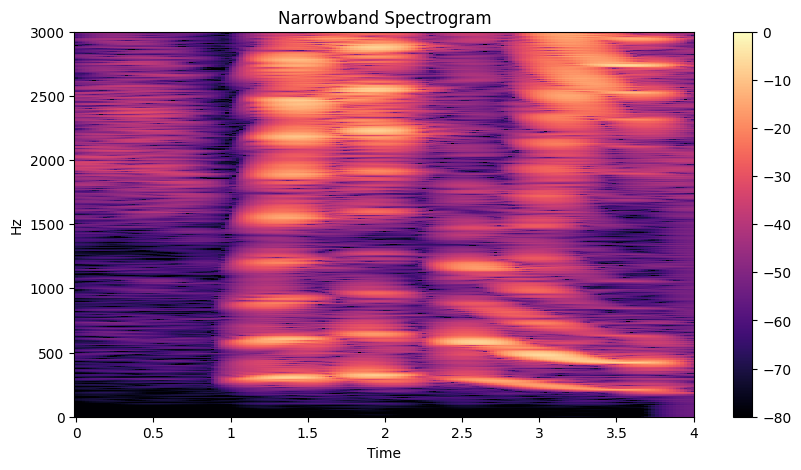

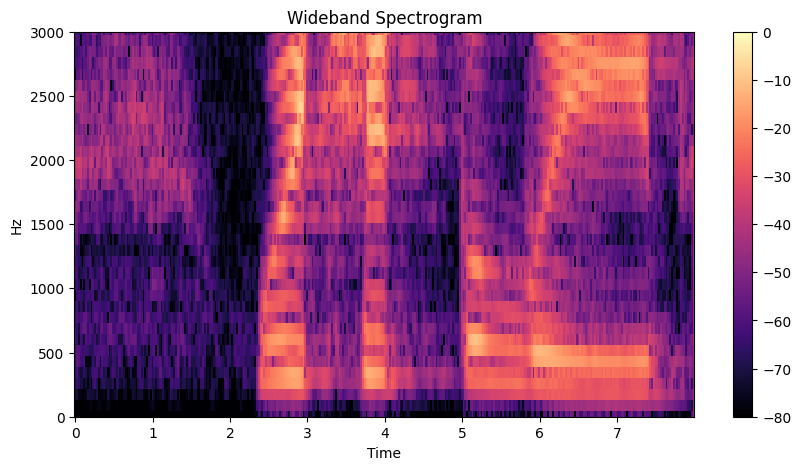


INFERENCE:
FFT shows frequency components clearly but lacks time variation.
STFT shows time-varying features of speech.
Pitch contour shows how pitch changes over time.
Narrowband spectrogram highlights harmonics clearly.
Wideband spectrogram highlights pitch pulses clearly.
There is a trade-off between time and frequency resolution.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

file_path = "/content/LJ050-0274.wav"
y, sr = librosa.load(file_path, sr=None)

print("Sampling Rate:", sr)

signal_preemph = np.append(y[0], y[1:] - 0.97 * y[:-1])

fft_spectrum = np.fft.fft(y)
frequencies = np.fft.fftfreq(len(fft_spectrum), 1/sr)

positive_freqs = frequencies[:len(frequencies)//2]
magnitude = np.abs(fft_spectrum[:len(fft_spectrum)//2])

plt.figure(figsize=(10,5))
plt.plot(positive_freqs, magnitude)
plt.title("FFT Spectrum (Pitch, Harmonics, Formants)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid()
plt.show()


pitch_fft = positive_freqs[np.argmax(magnitude)]
print("Pitch from FFT (Hz):", pitch_fft)


stft = librosa.stft(y)
db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

plt.figure(figsize=(10,6))
librosa.display.specshow(db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram (STFT)")
plt.show()


pitches, magnitudes = librosa.piptrack(y=y, sr=sr)

pitch_contour = []
time_axis = librosa.frames_to_time(np.arange(pitches.shape[1]), sr=sr)

for i in range(pitches.shape[1]):
    index = magnitudes[:, i].argmax()
    pitch = pitches[index, i]
    pitch_contour.append(pitch if pitch > 0 else np.nan)

plt.figure(figsize=(10,4))
plt.plot(time_axis, pitch_contour, color='red')
plt.title("Pitch Contour over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()

def estimate_formants(signal, sr):
    emphasized = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])
    A = librosa.lpc(emphasized, order=12)
    roots = np.roots(A)
    roots = [r for r in roots if np.imag(r) >= 0]
    angles = np.angle(roots)
    formants = sorted(angles * (sr / (2 * np.pi)))
    return formants

formants = estimate_formants(y, sr)
print("Estimated Formants (Hz):", formants[:4])

plt.figure(figsize=(10,5))
plt.plot(positive_freqs, magnitude, label="FFT Spectrum")

for f in formants[:4]:
    plt.axvline(x=f, color='green', linestyle='--',
                label='Formant' if f == formants[0] else "")

plt.title("FFT with Formants")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.grid()
plt.show()


start = int(2 * sr)
end = int(3 * sr)
segment = signal_preemph[start:end]

D_narrow = librosa.stft(segment,
                        n_fft=4096,
                        hop_length=128,
                        win_length=4096)

S_db_narrow = librosa.amplitude_to_db(np.abs(D_narrow),
                                      ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db_narrow, sr=sr,
                         x_axis='time', y_axis='hz')
plt.ylim(0, 3000)
plt.title("Narrowband Spectrogram")
plt.colorbar()
plt.show()

D_wide = librosa.stft(segment,
                      n_fft=256,
                      hop_length=64,
                      win_length=256)

S_db_wide = librosa.amplitude_to_db(np.abs(D_wide),
                                    ref=np.max)

plt.figure(figsize=(10,5))
librosa.display.specshow(S_db_wide, sr=sr,
                         x_axis='time', y_axis='hz')
plt.ylim(0, 3000)
plt.title("Wideband Spectrogram")
plt.colorbar()
plt.show()

print("\nINFERENCE:")
print("FFT shows frequency components clearly but lacks time variation.")
print("STFT shows time-varying features of speech.")
print("Pitch contour shows how pitch changes over time.")
print("Narrowband spectrogram highlights harmonics clearly.")
print("Wideband spectrogram highlights pitch pulses clearly.")
print("There is a trade-off between time and frequency resolution.")